In [1]:
import yaml

import numpy as np
import matplotlib.pyplot as plt

import imprl.envs

## Baseline Plot (Any Setting Family)

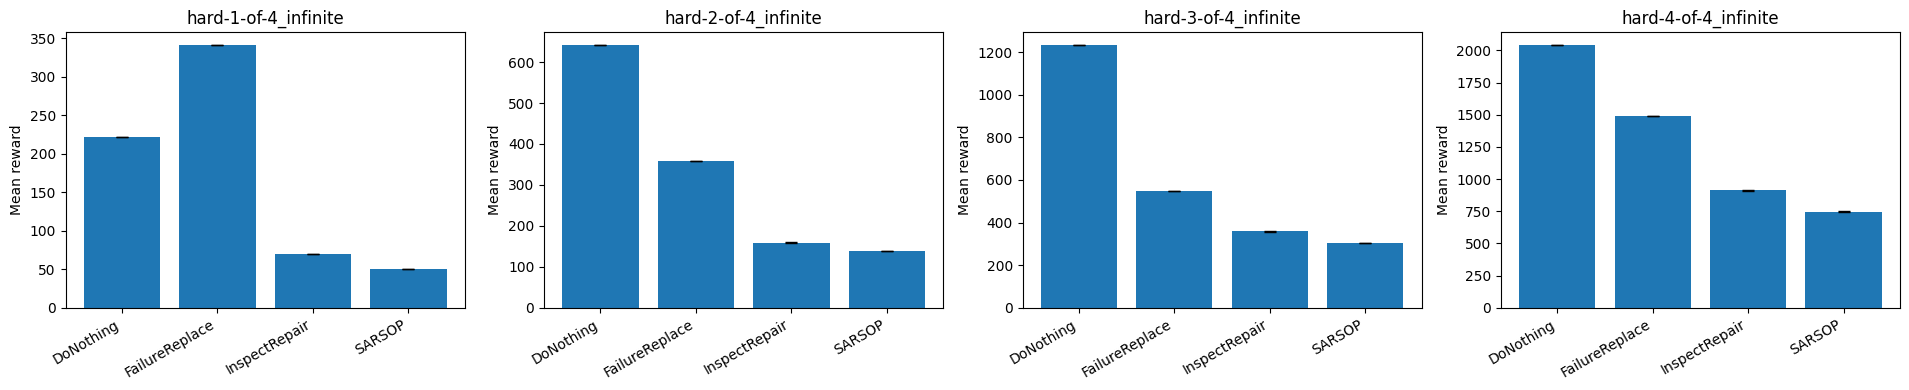

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
import imprl

ENV_NAME = "k_out_of_n_infinite"
BASELINES = ["DoNothing", "FailureReplace", "InspectRepair", "SARSOP"]

# Option 1: template + k range
SETTING_TEMPLATE = "hard-{k}-of-4_infinite"
K_VALUES = range(1, 5)
SETTINGS = [SETTING_TEMPLATE.format(k=k) for k in K_VALUES]

# Option 2: explicit settings list (uncomment to use)
# SETTINGS = ["hard-1-of-4_infinite", "hard-2-of-4_infinite"]

if not SETTINGS:
    raise ValueError("SETTINGS is empty. Provide at least one setting.")

n = len(SETTINGS)
ncols = min(4, n)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4.8 * ncols, 4.0 * nrows), squeeze=False)
axes = axes.flatten()

for idx, setting in enumerate(SETTINGS):
    env = imprl.envs.make(ENV_NAME, setting)

    means, labels = [], []
    low_err, high_err = [], []

    for baseline in BASELINES:
        entry = env.core.baselines.get(baseline, {})
        mean_val = entry.get("mean", np.nan)
        ci = entry.get("95_ci", None)

        labels.append(baseline)
        means.append(mean_val)

        if ci is not None and isinstance(ci, (list, tuple)) and len(ci) == 2 and np.isfinite(mean_val):
            lower, upper = ci
            low_err.append(max(0.0, mean_val - lower))
            high_err.append(max(0.0, upper - mean_val))
        else:
            low_err.append(0.0)
            high_err.append(0.0)

    ax = axes[idx]
    x = np.arange(len(labels))
    yerr = np.vstack([low_err, high_err])

    ax.bar(x, means, yerr=yerr, capsize=4)
    ax.set_title(setting)
    ax.set_ylabel("Mean reward")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")

for i in range(n, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()